Processed 1% Bank CAT data: 1500 steps
Processed Full Bank CAT data: 1500 steps
Processed Naive CAT data: 1500 steps


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_92805/1795095543.py:86: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


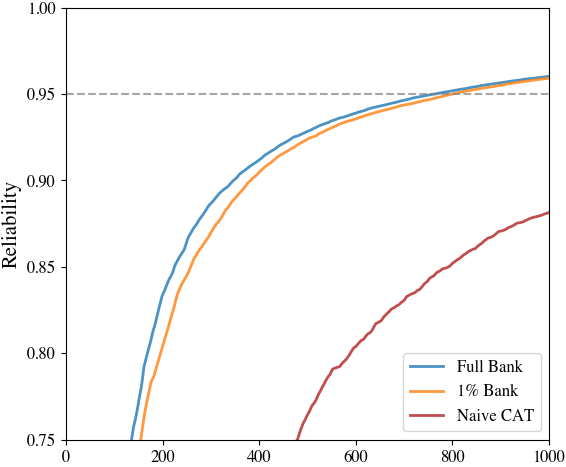

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, sys
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)

# =============================================================================
# 1. LOAD THE SIMULATION HISTORY
# =============================================================================

# Define the paths to your results files
output_dir = "../result"
small_file_path = os.path.join(output_dir, "single_person_cat_history_with_reliability_780.csv")
large_file_path = os.path.join(output_dir, "single_person_cat_history_with_reliability_78712.csv")
naive_file_path = os.path.join(output_dir, "naive_cat_history_with_reliability.csv")

df_small = pd.read_csv(small_file_path)
df_large = pd.read_csv(large_file_path)
df_naive = pd.read_csv(naive_file_path)

# =============================================================================
# 2. CALCULATE AVERAGE METRICS FOR BOTH DATASETS
# =============================================================================

def process_cat_data(df, label):
    """Process CAT data to calculate average metrics and smoothing."""
    if df is None:
        return None
    
    # Find all SEM and reliability columns in the DataFrame
    sem_cols = [col for col in df.columns if col.startswith('sem_')]
    reliability_cols = [col for col in df.columns if col.startswith('reliability_')]

    # Calculate the average across all dimensions for each step (row)
    df['avg_sem'] = df[sem_cols].mean(axis=1)
    df['avg_reliability'] = df[reliability_cols].mean(axis=1)

    # Apply smoothing using rolling mean
    window_size = 5  # Define the window size for smoothing
    df['avg_sem_smooth'] = df['avg_sem'].rolling(window=window_size, min_periods=1).mean()
    df['avg_reliability_smooth'] = df['avg_reliability'].rolling(window=window_size, min_periods=1).mean()
    
    print(f"Processed {label} CAT data: {len(df)} steps")
    return df

# Process both datasets
df_small_processed = process_cat_data(df_small, "1% Bank")
df_large_processed = process_cat_data(df_large, "Full Bank")
df_naive_processed = process_cat_data(df_naive, "Naive")

# =============================================================================
# 3. PLOT THE COMPARISON
# =============================================================================

# Create a figure and a primary y-axis for Reliability
fig, ax1 = plt.subplots(figsize=(6, 5))

# Plot Intelligent CAT (Smoothed Average Reliability)
ax1.plot(df_large_processed['step'], df_large_processed['avg_reliability_smooth'], 
            color='C0', linewidth=2, label='Full Bank', alpha=0.8)
ax1.plot(df_small_processed['step'], df_small_processed['avg_reliability_smooth'], 
            color='C1', linewidth=2, label='1% Bank', alpha=0.8)
# Plot Naive CAT (Smoothed Average Reliability)
ax1.plot(df_naive_processed['step'], df_naive_processed['avg_reliability_smooth'], 
            color='firebrick', linewidth=2, label='Naive CAT', alpha=0.8)

ax1.set_ylabel('Reliability', fontsize=15)
ax1.tick_params(axis='y')
ax1.set_ylim(0.75, 1.0)

# Add a horizontal line for a common reliability target
ax1.axhline(y=0.95, color='gray', linestyle='--', alpha=0.7)

# Synchronize the ticks on the y-axis
ax1.yaxis.set_major_locator(mticker.LinearLocator(numticks=6))
ax1.grid(False)

# Set x-axis limits
ax1.set_xlim(0, 1000)

# Add legend
ax1.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.savefig("../result/reliability_comparison_CAT.pdf", dpi=300, bbox_inches='tight')
plt.show()